In [32]:
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (13, 7)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["figure.dpi"] = 110

STATIC  = "PennAir 2024 App Static.png"
DYNAMIC = "PennAir 2024 App Dynamic.mp4"
HARD    = "PennAir 2024 App Dynamic Hard.mp4"

BUDGET_MS = 1000 / 30   # real-time at 30 fps -- the number to beat on video

In [33]:
def show(images, titles=None, scale=None, cols=None):
    """Draw images / maps in a row, inline.

    images : BGR uint8 arrays, or single-channel arrays of any dtype
    titles : optional list of captions
    scale  : (lo, hi) to fix the grayscale range; None auto-scales each map
    cols   : wrap onto multiple rows after this many
    """
    n = len(images)
    cols = cols or n
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, squeeze=False,
                             figsize=(plt.rcParams["figure.figsize"][0],
                                      4.2 * rows))
    for ax in axes.ravel():
        ax.axis("off")
    for i, img in enumerate(images):
        ax = axes.ravel()[i]
        a = np.asarray(img)
        if a.ndim == 3 and a.shape[2] == 3:
            ax.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
        else:
            lo, hi = scale if scale else (float(a.min()), float(a.max()))
            ax.imshow(a.squeeze(), cmap="gray", vmin=lo, vmax=hi)
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10)
    fig.tight_layout()
    plt.show()


def hist(values, bins=200, log=True, vline=None, title=None):
    """Histogram of a measurement map -- for picking a threshold by eye.

    `vline` draws a candidate cutoff on top of it.
    """
    plt.figure(figsize=(9, 3))
    plt.hist(np.asarray(values).ravel(), bins=bins, log=log)
    plt.title(title)
    if vline is not None:
        plt.axvline(vline, color="r", lw=1)
    plt.tight_layout()
    plt.show()

In [34]:
def image(path=STATIC):
    """The static image, as BGR uint8."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return img


def frame(path, index=0):
    """One frame of a video by index.  Convenience for poking around."""
    cap = cv2.VideoCapture(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, img = cap.read()
    cap.release()
    if not ok:
        raise IOError(f"could not read frame {index} of {path}")
    return img


def frames(path, count=4):
    """`count` frames spread evenly across a video."""
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out = []
    for i in np.linspace(0, max(total - 2, 0), count).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, img = cap.read()
        if ok:
            out.append(img)
    cap.release()
    return out


def stream(path, count=None, start=0):
    """Yield frames sequentially, one at a time.  No seeking, no lookahead."""
    cap = cv2.VideoCapture(path)
    try:
        for i in range(start):
            if not cap.read()[0]:
                return
        n = 0
        while count is None or n < count:
            ok, img = cap.read()
            if not ok:
                return
            yield img
            n += 1
    finally:
        cap.release()

In [35]:
OUTLINE, CENTER, STATUS = (255, 0, 0), (0, 0, 255), (255, 255, 255)
FONT = cv2.FONT_HERSHEY_SIMPLEX


def centroid(contour):
    """Centre of mass of a contour, or None if it has zero area."""
    m = cv2.moments(contour)
    if m["m00"] == 0:
        return None
    return int(m["m10"] / m["m00"]), int(m["m01"] / m["m00"])


def annotate(img, contours, status=None):
    """Copy of `img` with each contour outlined and its centre marked."""
    vis = img.copy()
    cv2.drawContours(vis, list(contours), -1, OUTLINE, 2, cv2.LINE_AA)
    for contour in contours:
        point = centroid(contour)
        if point is None:
            continue
        cv2.drawMarker(vis, point, CENTER, cv2.MARKER_CROSS, 16, 2, cv2.LINE_AA)
        _text(vis, f"({point[0]}, {point[1]})",
              (point[0] + 12, point[1] - 12), 0.5, CENTER)
    if status:
        _text(vis, status, (12, 34), 0.7, STATUS)
    return vis


def _text(img, s, origin, scale, color):
    # Black pass first, so text stays readable over bright shapes and dark
    # background alike.
    cv2.putText(img, s, origin, FONT, scale, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(img, s, origin, FONT, scale, color, 1, cv2.LINE_AA)

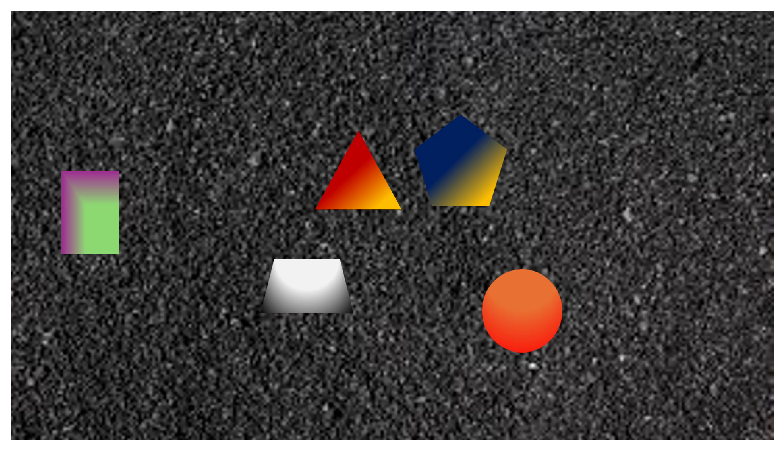

In [36]:
img = frame(HARD, 211)
show([img])

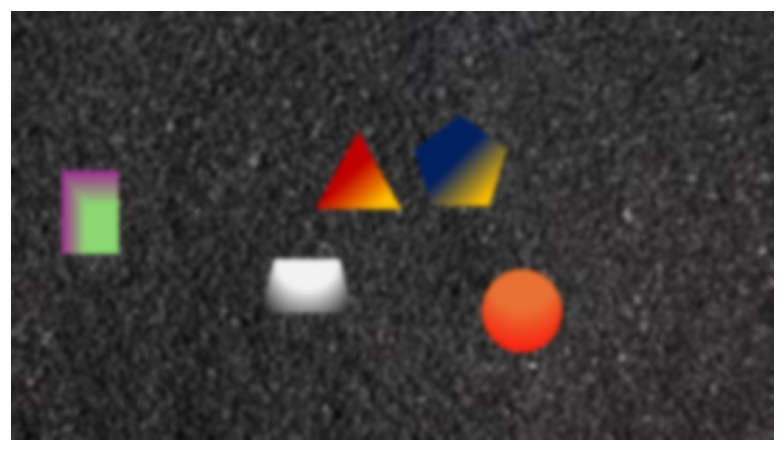

In [37]:
gb = cv2.GaussianBlur(img, (41, 41), sigmaX=0)
show([gb])

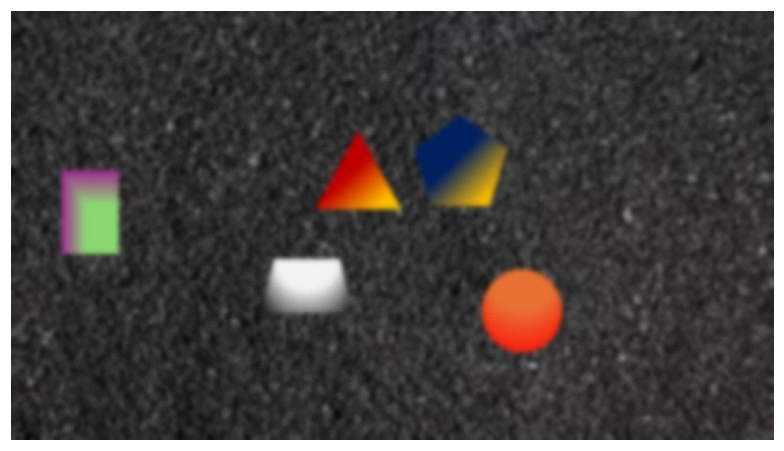

In [38]:
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

sharpened_image = cv2.filter2D(gb, ddepth=-1, kernel=sharpen_kernel)
show([sharpened_image])

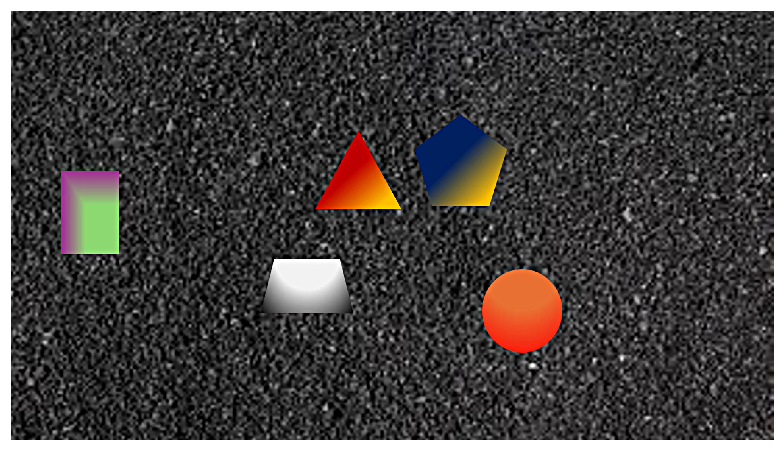

In [39]:
unsharp_image = cv2.addWeighted(img, 1.5, gb, -0.5, 0)
show([unsharp_image])

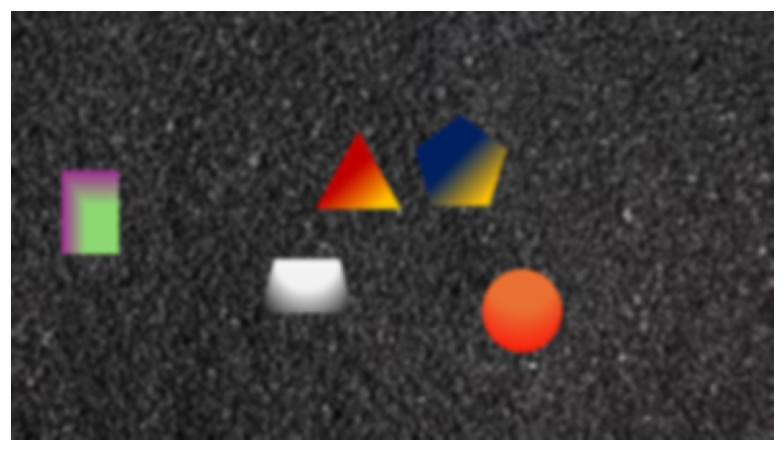

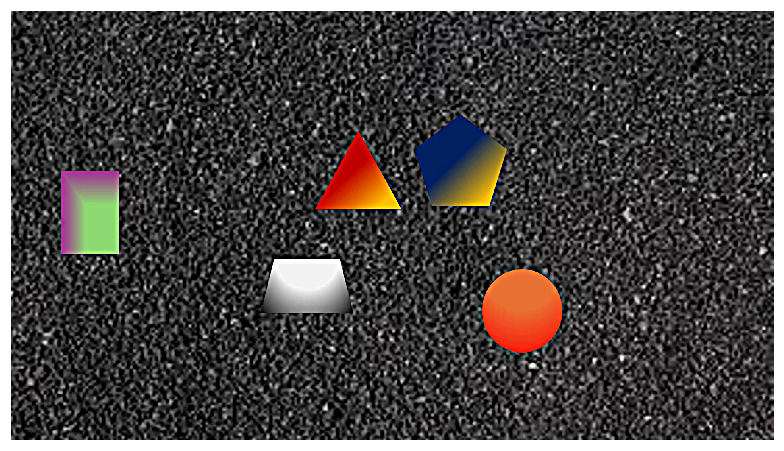

In [40]:
gb2 = cv2.GaussianBlur(unsharp_image, (41, 41), sigmaX=0)
show([gb2])
unsharp_image2 = cv2.addWeighted(unsharp_image, 1.5, gb2, -0.5, 0)
show([unsharp_image2])

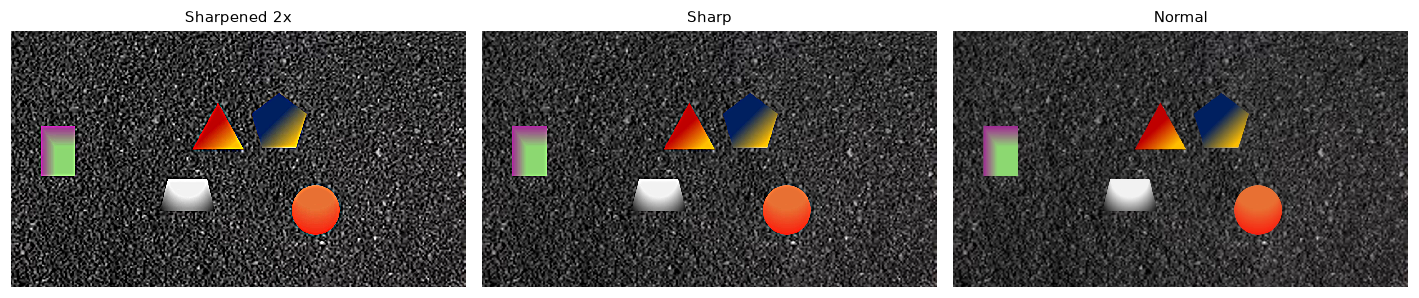

In [41]:
show([unsharp_image2, unsharp_image, img], ["Sharpened 2x", "Sharp", "Normal"])

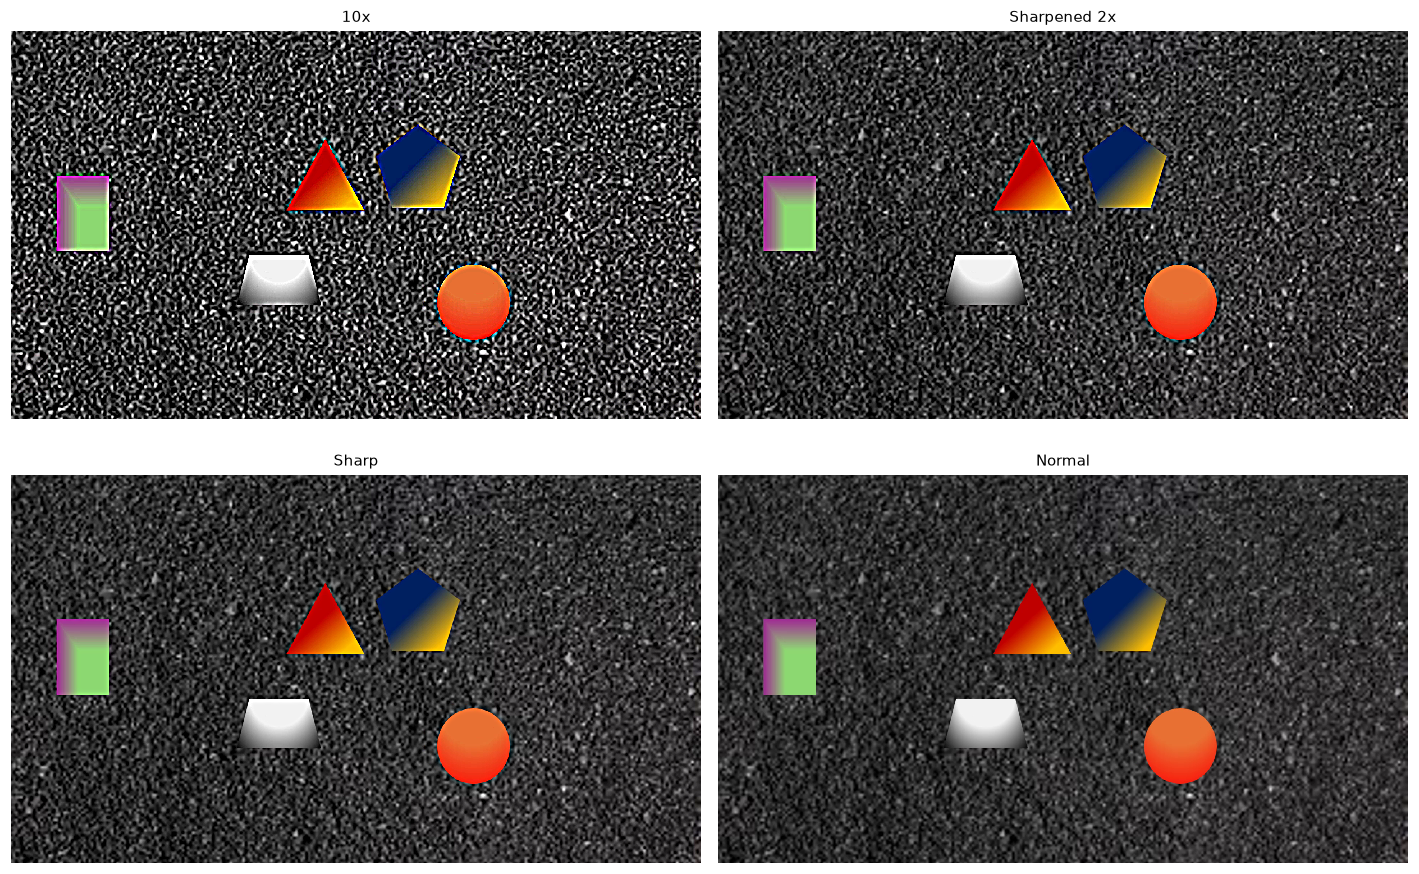

In [42]:
cur_img = np.copy(img)
for i in range(4):
    gb_cur = cv2.GaussianBlur(cur_img, (41, 41), sigmaX=0)
    ui = cv2.addWeighted(cur_img, 1.5, gb2, -0.5, 0)
    cur_img = ui

show([cur_img, unsharp_image2, unsharp_image, img], ["10x", "Sharpened 2x", "Sharp", "Normal"], cols=2)